# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/leofire123/indian-flight-delay-datasets/india_flight_delay_model_input.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/leofire123/indian-flight-delay-datasets/india_flight_delay_model_input.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure_Hour,Scheduled_Departure_Minute,Day_of_Week,Month,Is_Weekend,...,Humidity_pct,Wind_Speed_kmh,Visibility_km,Rainfall_mm,Cloud_Cover_pct,Origin_Congestion_Index,Previous_Flight_Delay_Minutes,Turnaround_Risk_Index,Departure_Delay,Delay_Target
0,2025-12-04,IndiGo,IN8723,BOM,DEL,13,57,3,12,0,...,46.1,4.3,9.8,5.2,0.0,63.5,0,23.9,43,1
1,2024-01-15,IndiGo,IN558,CCU,HYD,19,14,0,1,0,...,70.5,8.9,11.7,0.4,39.8,95.3,1,31.5,49,1
2,2023-11-06,Vistara,VI4949,HYD,DEL,8,50,0,11,0,...,53.7,7.8,9.6,4.3,16.6,100.0,1,41.5,73,1
3,2025-08-08,SpiceJet,SP3196,BLR,DIB,11,56,4,8,0,...,42.0,1.5,12.6,4.6,23.6,51.1,1,28.2,40,1
4,2023-09-09,IndiGo,IN8458,BLR,JGA,22,59,5,9,1,...,58.5,1.3,11.3,3.5,36.2,67.0,0,27.9,0,0


## last Five row

In [4]:
df.tail()

,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure_Hour,Scheduled_Departure_Minute,Day_of_Week,Month,Is_Weekend,...,Humidity_pct,Wind_Speed_kmh,Visibility_km,Rainfall_mm,Cloud_Cover_pct,Origin_Congestion_Index,Previous_Flight_Delay_Minutes,Turnaround_Risk_Index,Departure_Delay,Delay_Target
149995,2024-07-08,IndiGo,IN5273,BOM,AMD,5,49,0,7,0,...,55.3,14.0,11.1,0.8,25.7,78.2,0,46.1,51,1
149996,2025-03-21,Air India Express,AI8983,COK,DEL,11,32,4,3,0,...,80.3,2.3,11.2,0.0,29.1,73.7,8,40.4,46,1
149997,2023-04-11,IndiGo,IN2669,DEL,CCU,9,6,1,4,0,...,36.7,2.2,9.8,0.1,32.8,84.8,7,40.5,50,1
149998,2025-05-04,Air India,AI8266,IXR,COK,6,42,6,5,1,...,53.8,3.5,8.8,3.0,16.6,35.5,0,21.0,0,0
149999,2024-06-17,Fly91,FL5153,MAA,DEL,9,20,0,6,0,...,53.5,12.5,9.8,3.0,25.5,91.8,6,42.8,53,1


## Shape of our dataset

In [5]:
df.shape

(150000, 23)

## List out all columns

In [6]:
df.columns

Index(['Flight_Date', 'Airline', 'Flight_Number', 'Origin_Airport',
       'Destination_Airport', 'Scheduled_Departure_Hour',
       'Scheduled_Departure_Minute', 'Day_of_Week', 'Month', 'Is_Weekend',
       'Peak_Hour', 'Weather', 'Temperature_C', 'Humidity_pct',
       'Wind_Speed_kmh', 'Visibility_km', 'Rainfall_mm', 'Cloud_Cover_pct',
       'Origin_Congestion_Index', 'Previous_Flight_Delay_Minutes',
       'Turnaround_Risk_Index', 'Departure_Delay', 'Delay_Target'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Flight_Date                       object
Airline                           object
Flight_Number                     object
Origin_Airport                    object
Destination_Airport               object
Scheduled_Departure_Hour           int64
Scheduled_Departure_Minute         int64
Day_of_Week                        int64
Month                              int64
Is_Weekend                         int64
Peak_Hour                          int64
Weather                           object
Temperature_C                    float64
Humidity_pct                     float64
Wind_Speed_kmh                   float64
Visibility_km                    float64
Rainfall_mm                      float64
Cloud_Cover_pct                  float64
Origin_Congestion_Index          float64
Previous_Flight_Delay_Minutes      int64
Turnaround_Risk_Index            float64
Departure_Delay                    int64
Delay_Target                       int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Flight_Date                    150000 non-null  object 
 1   Airline                        150000 non-null  object 
 2   Flight_Number                  150000 non-null  object 
 3   Origin_Airport                 150000 non-null  object 
 4   Destination_Airport            150000 non-null  object 
 5   Scheduled_Departure_Hour       150000 non-null  int64  
 6   Scheduled_Departure_Minute     150000 non-null  int64  
 7   Day_of_Week                    150000 non-null  int64  
 8   Month                          150000 non-null  int64  
 9   Is_Weekend                     150000 non-null  int64  
 10  Peak_Hour                      150000 non-null  int64  
 11  Weather                        150000 non-null  object 
 12  Temperature_C                 

## Check Null Value

In [9]:
df.isnull().sum()

Flight_Date                      0
Airline                          0
Flight_Number                    0
Origin_Airport                   0
Destination_Airport              0
Scheduled_Departure_Hour         0
Scheduled_Departure_Minute       0
Day_of_Week                      0
Month                            0
Is_Weekend                       0
Peak_Hour                        0
Weather                          0
Temperature_C                    0
Humidity_pct                     0
Wind_Speed_kmh                   0
Visibility_km                    0
Rainfall_mm                      0
Cloud_Cover_pct                  0
Origin_Congestion_Index          0
Previous_Flight_Delay_Minutes    0
Turnaround_Risk_Index            0
Departure_Delay                  0
Delay_Target                     0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Scheduled_Departure_Hour,Scheduled_Departure_Minute,Day_of_Week,Month,Is_Weekend,Peak_Hour,Temperature_C,Humidity_pct,Wind_Speed_kmh,Visibility_km,Rainfall_mm,Cloud_Cover_pct,Origin_Congestion_Index,Previous_Flight_Delay_Minutes,Turnaround_Risk_Index,Departure_Delay,Delay_Target
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,14.001260,29.533773,2.997107,6.512973,0.286820,0.47528,27.028051,56.332991,5.993765,10.891581,1.666205,25.013692,72.406212,6.170807,35.715187,42.664340,0.866167
std,5.480291,17.322034,2.003977,3.445167,0.452278,0.49939,5.489234,10.161597,4.223185,1.271557,2.409718,13.020552,19.277706,6.483483,8.719541,19.016712,0.340474
min,5.000000,0.000000,0.000000,1.000000,0.000000,0.00000,10.000000,20.000000,0.000000,5.100000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000
25%,9.000000,15.000000,1.000000,4.000000,0.000000,0.00000,22.900000,49.500000,2.900000,10.000000,0.000000,15.800000,60.900000,1.000000,29.900000,39.000000,1.000000
50%,14.000000,30.000000,3.000000,7.000000,0.000000,0.00000,27.000000,56.300000,5.000000,10.900000,0.600000,24.800000,72.700000,4.000000,35.700000,47.000000,1.000000
75%,19.000000,45.000000,5.000000,10.000000,1.000000,1.00000,31.100000,63.200000,8.100000,11.700000,2.500000,33.800000,88.800000,9.000000,41.500000,54.000000,1.000000
max,23.000000,59.000000,6.000000,12.000000,1.000000,1.00000,45.000000,100.000000,35.000000,15.000000,30.400000,90.100000,100.000000,71.000000,88.200000,119.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

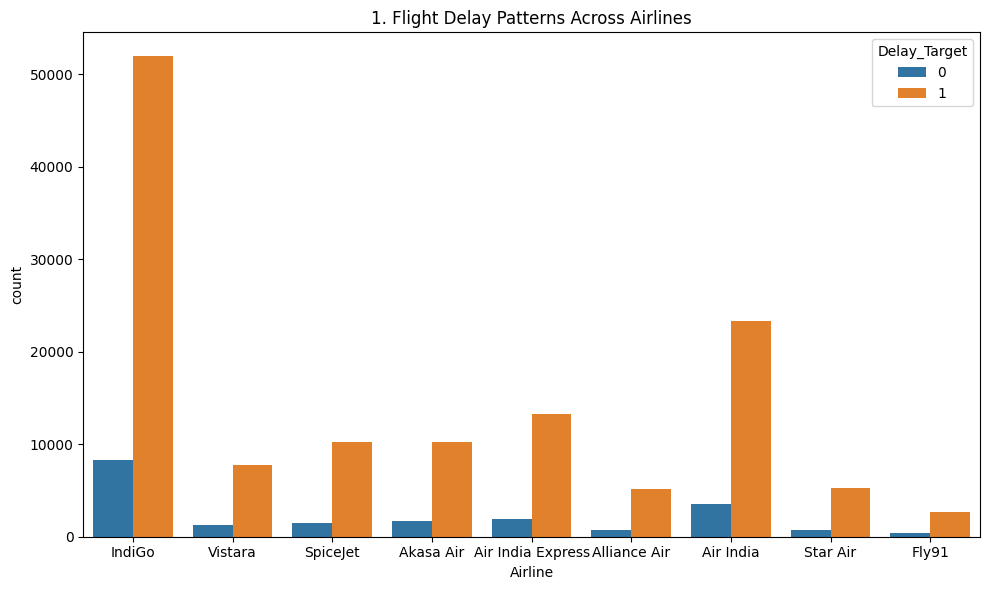

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Airline', hue='Delay_Target')
plt.title(f'{plot_no}. Flight Delay Patterns Across Airlines')
show_fig()
plot_no += 1

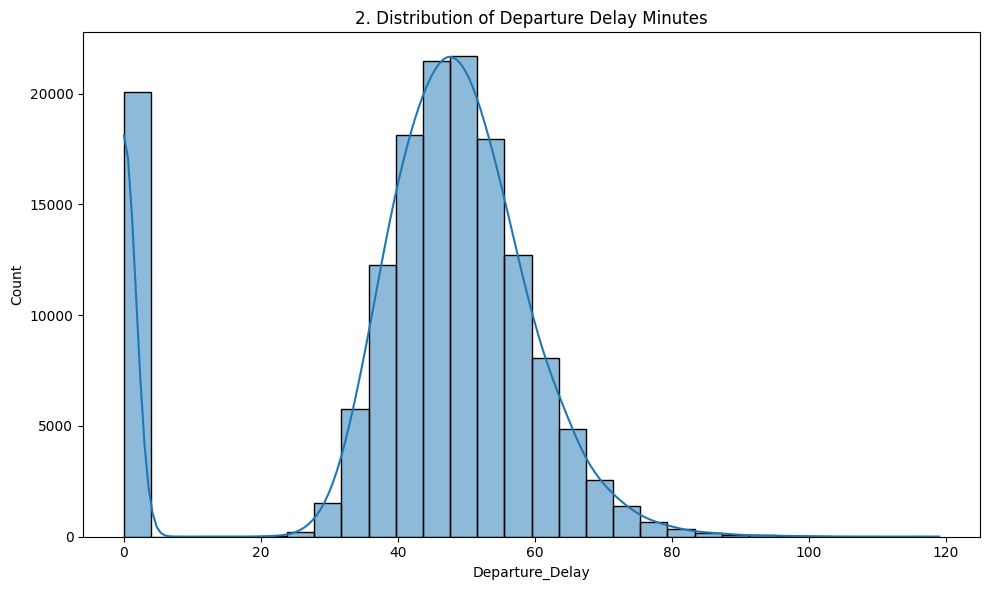

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Departure_Delay', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Departure Delay Minutes')
show_fig()
plot_no += 1

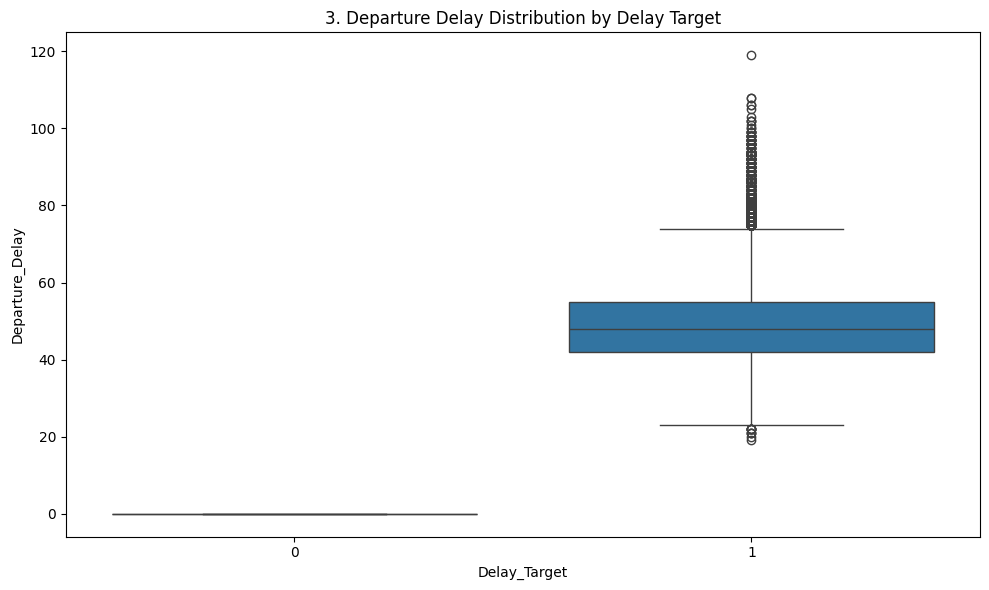

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Delay_Target', y='Departure_Delay')
plt.title(f'{plot_no}. Departure Delay Distribution by Delay Target')
show_fig()
plot_no += 1

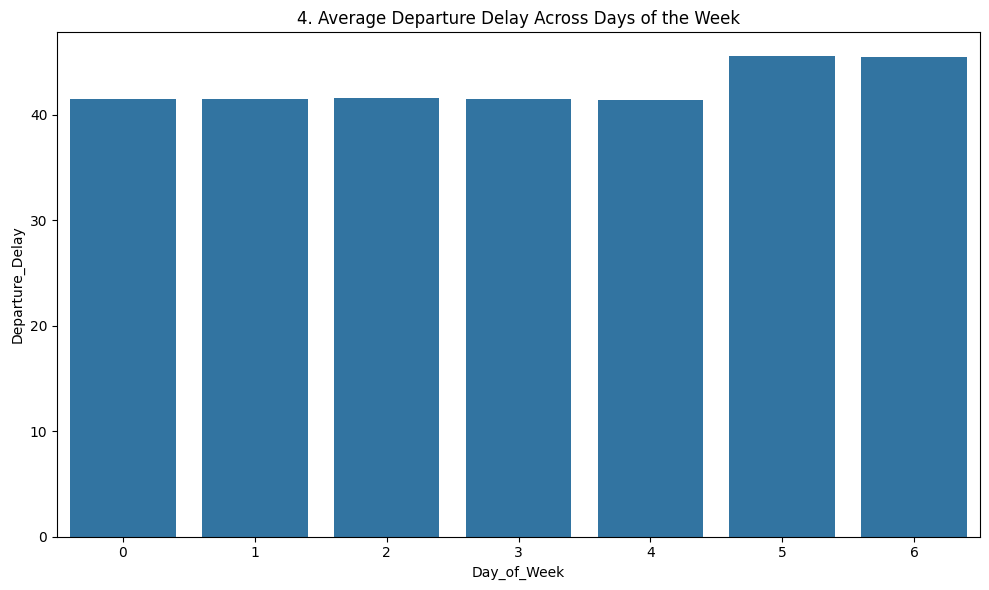

In [16]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Day_of_Week', y='Departure_Delay', errorbar=None)
plt.title(f'{plot_no}. Average Departure Delay Across Days of the Week')
show_fig()
plot_no += 1

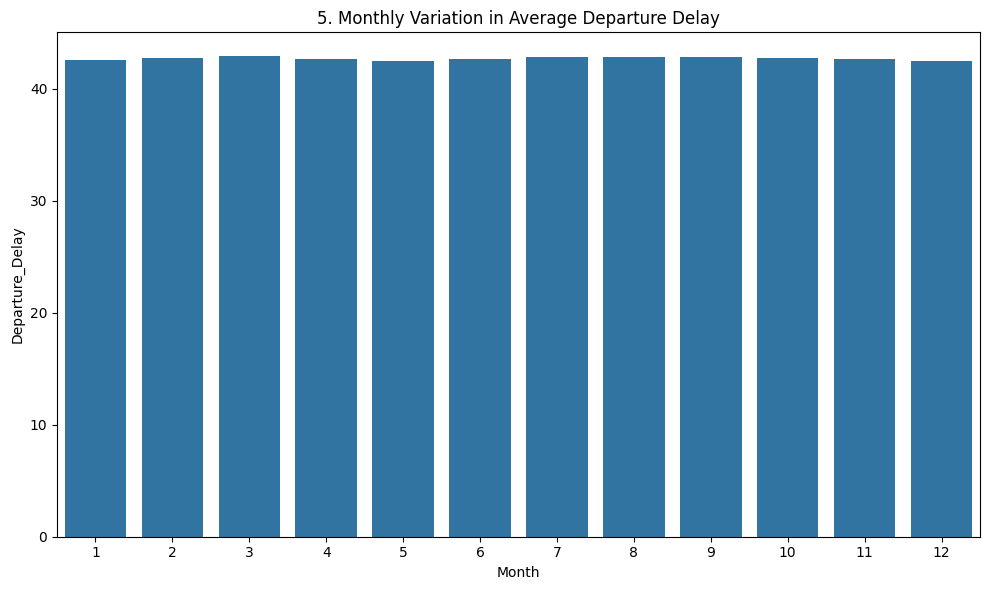

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Month', y='Departure_Delay', errorbar=None)
plt.title(f'{plot_no}. Monthly Variation in Average Departure Delay')
show_fig()
plot_no += 1

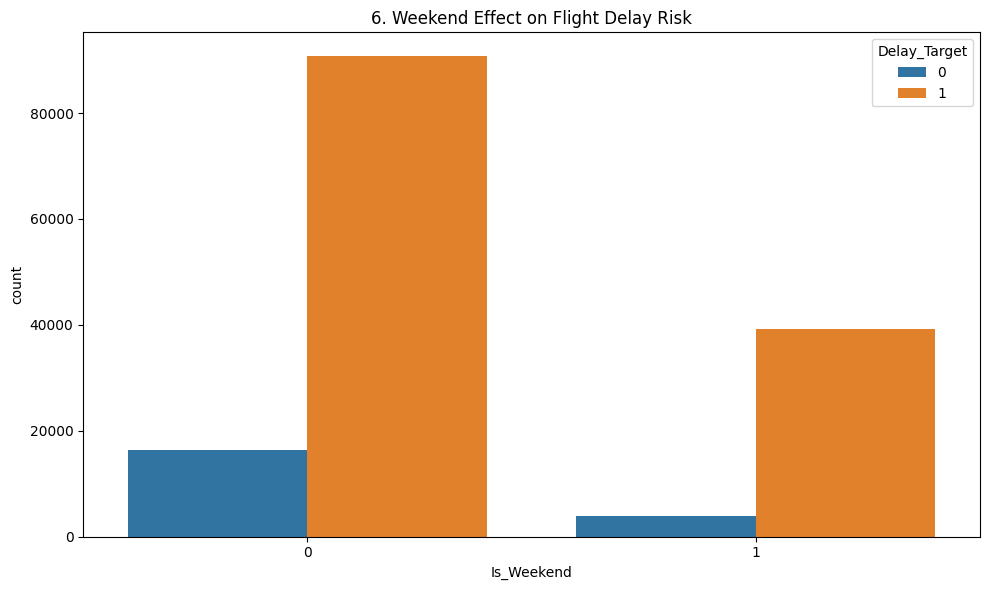

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Is_Weekend', hue='Delay_Target')
plt.title(f'{plot_no}. Weekend Effect on Flight Delay Risk')
show_fig()
plot_no += 1

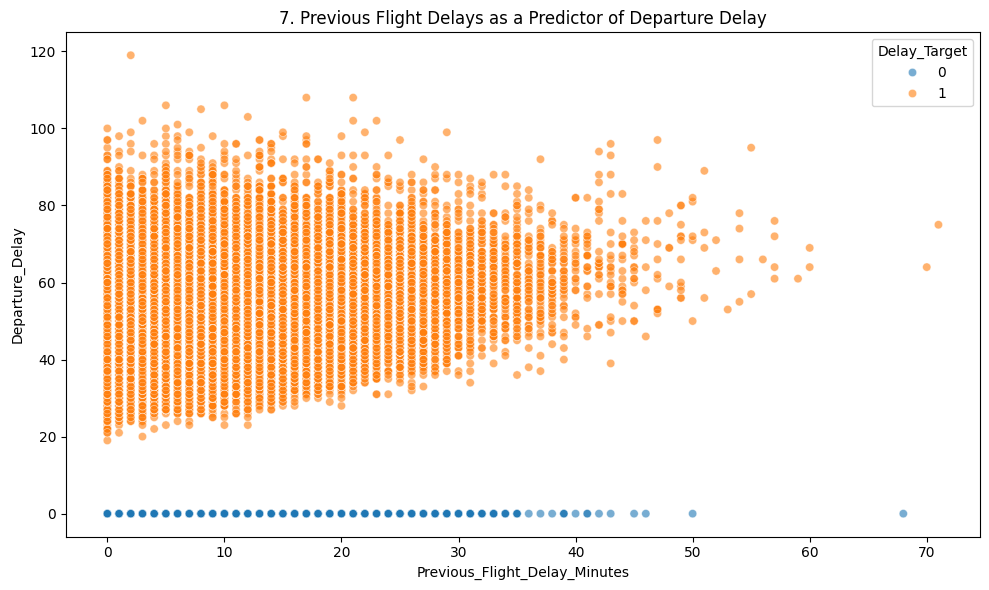

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Previous_Flight_Delay_Minutes', y='Departure_Delay', hue='Delay_Target', alpha=0.6)
plt.title(f'{plot_no}. Previous Flight Delays as a Predictor of Departure Delay')
show_fig()
plot_no += 1

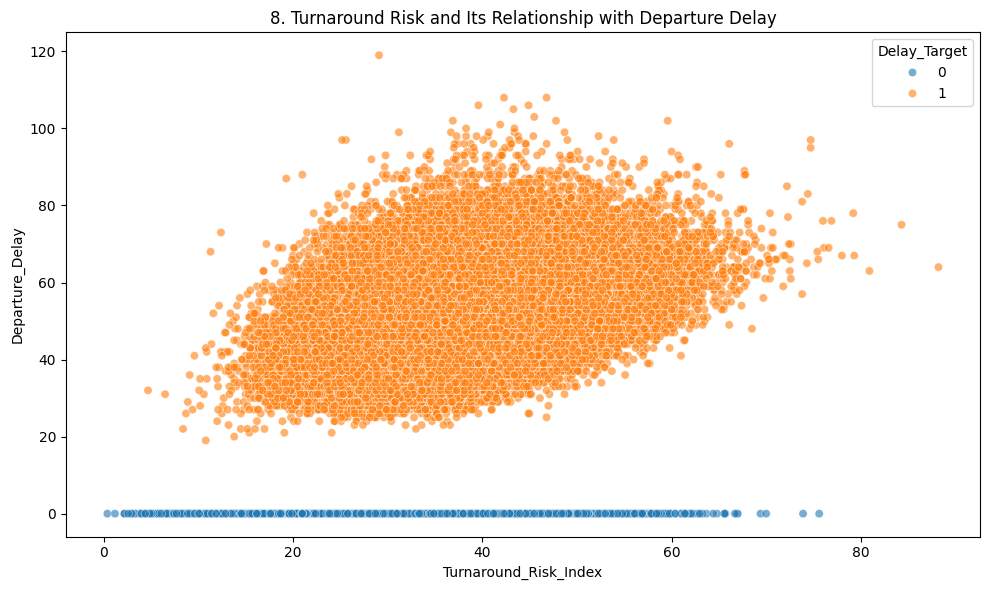

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Turnaround_Risk_Index', y='Departure_Delay', hue='Delay_Target', alpha=0.6)
plt.title(f'{plot_no}. Turnaround Risk and Its Relationship with Departure Delay')
show_fig()
plot_no += 1

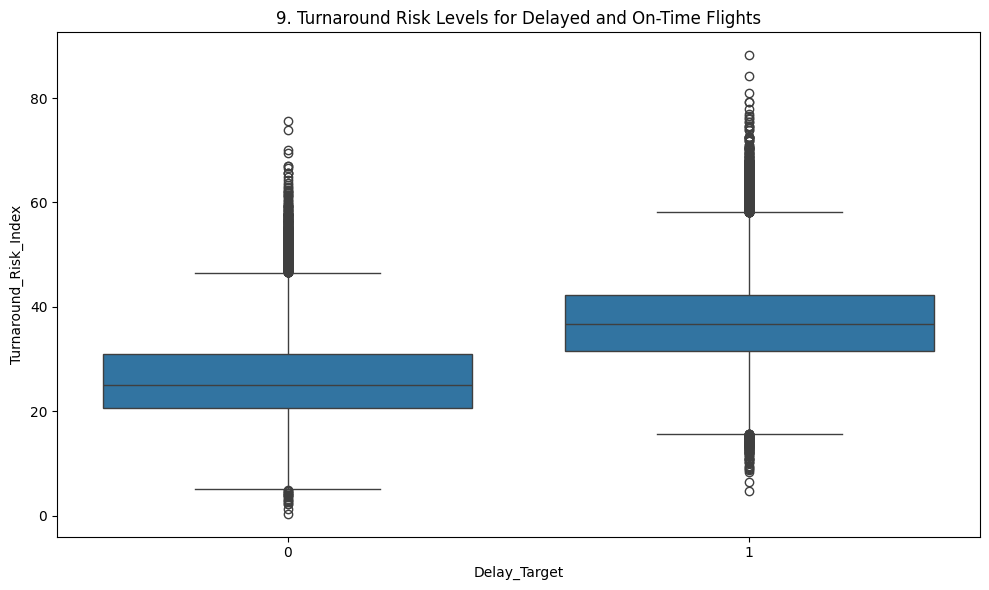

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Delay_Target', y='Turnaround_Risk_Index')
plt.title(f'{plot_no}. Turnaround Risk Levels for Delayed and On-Time Flights')
show_fig()
plot_no += 1

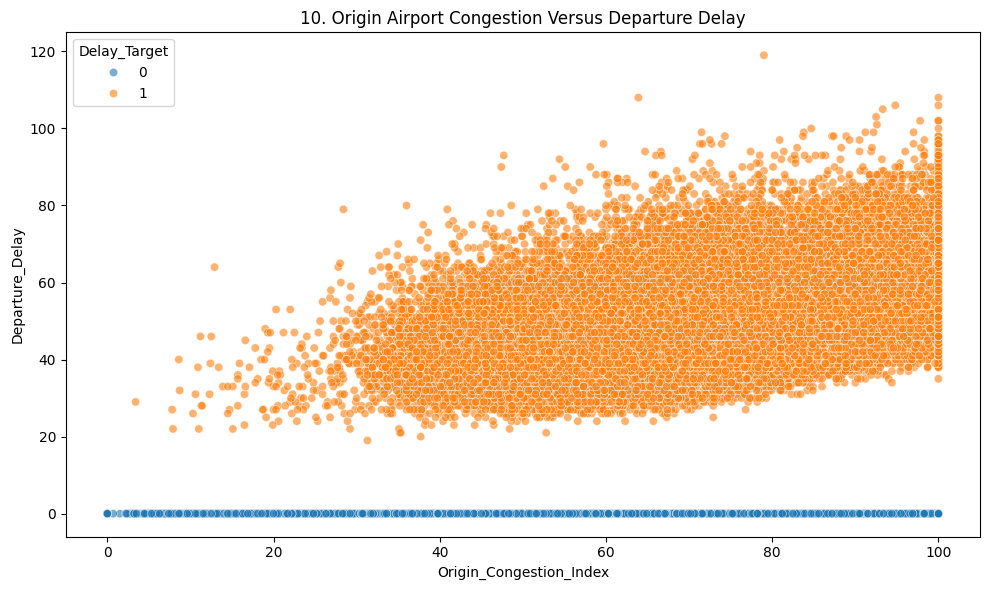

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Origin_Congestion_Index', y='Departure_Delay', hue='Delay_Target', alpha=0.6)
plt.title(f'{plot_no}. Origin Airport Congestion Versus Departure Delay')
show_fig()
plot_no += 1

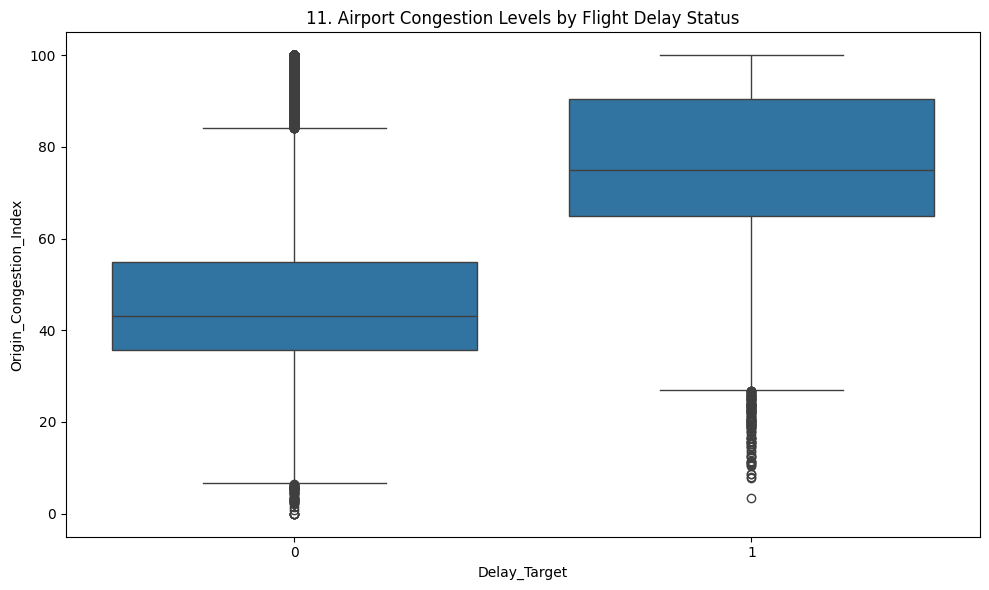

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Delay_Target', y='Origin_Congestion_Index')
plt.title(f'{plot_no}. Airport Congestion Levels by Flight Delay Status')
show_fig()
plot_no += 1

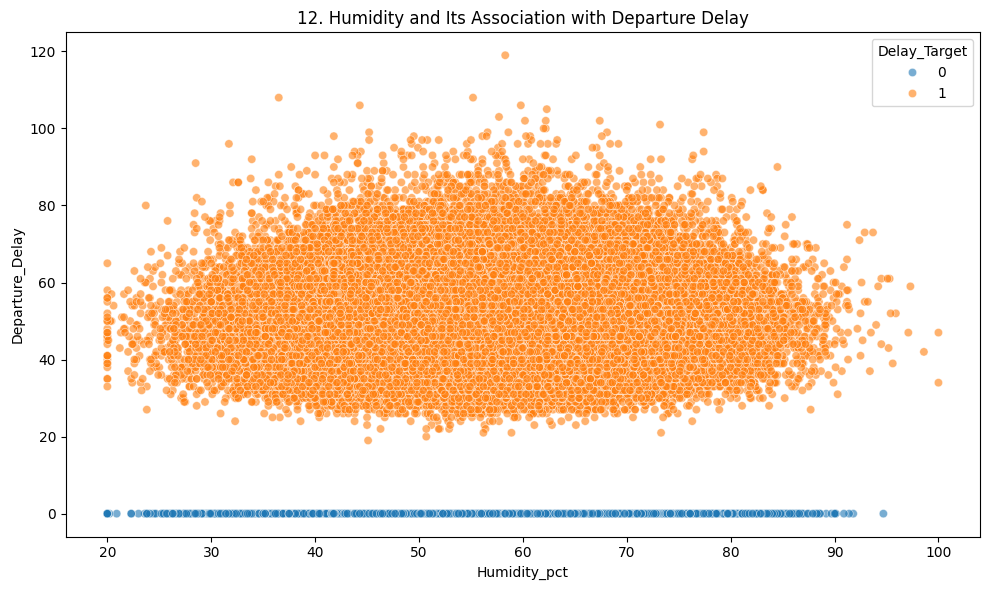

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Humidity_pct', y='Departure_Delay', hue='Delay_Target', alpha=0.6)
plt.title(f'{plot_no}. Humidity and Its Association with Departure Delay')
show_fig()
plot_no += 1

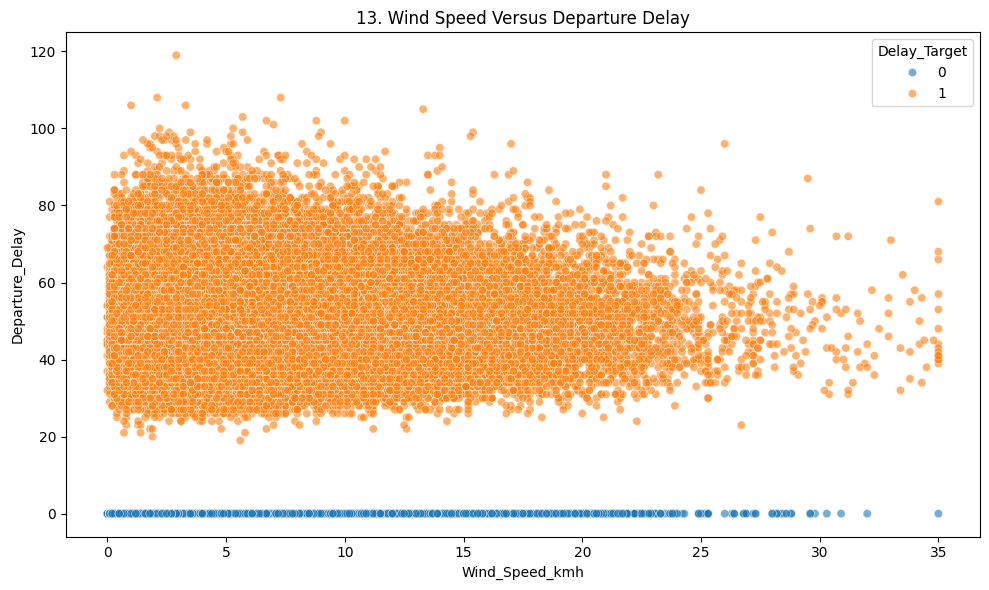

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Wind_Speed_kmh', y='Departure_Delay', hue='Delay_Target', alpha=0.6)
plt.title(f'{plot_no}. Wind Speed Versus Departure Delay')
show_fig()
plot_no += 1

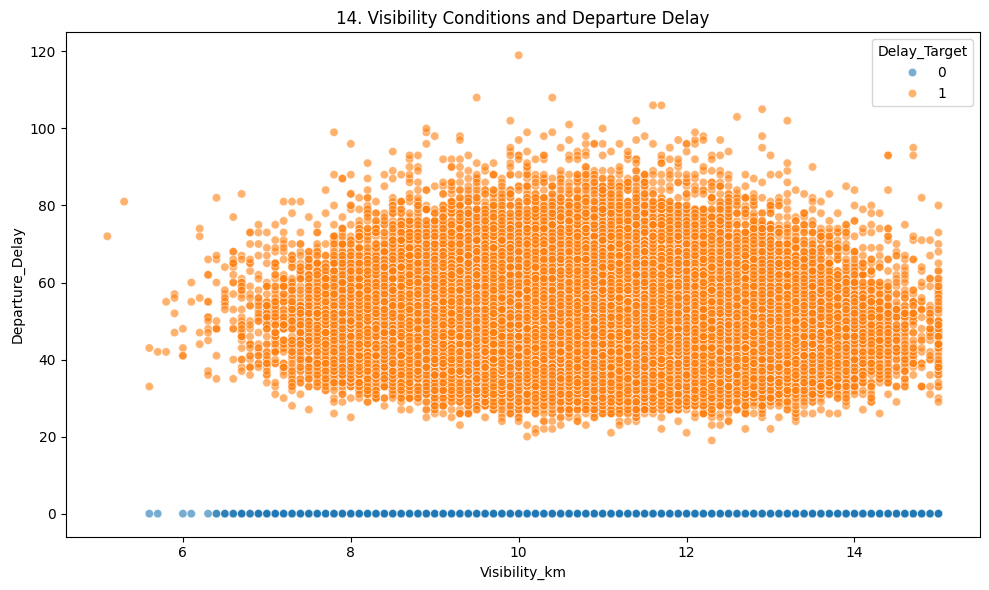

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Visibility_km', y='Departure_Delay', hue='Delay_Target', alpha=0.6)
plt.title(f'{plot_no}. Visibility Conditions and Departure Delay')
show_fig()
plot_no += 1

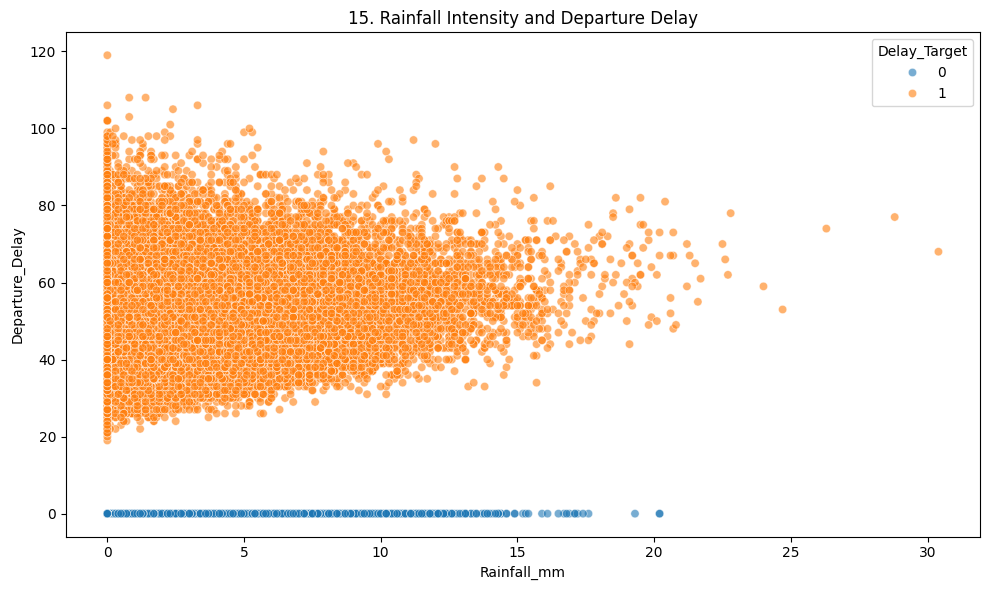

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Departure_Delay', hue='Delay_Target', alpha=0.6)
plt.title(f'{plot_no}. Rainfall Intensity and Departure Delay')
show_fig()
plot_no += 1

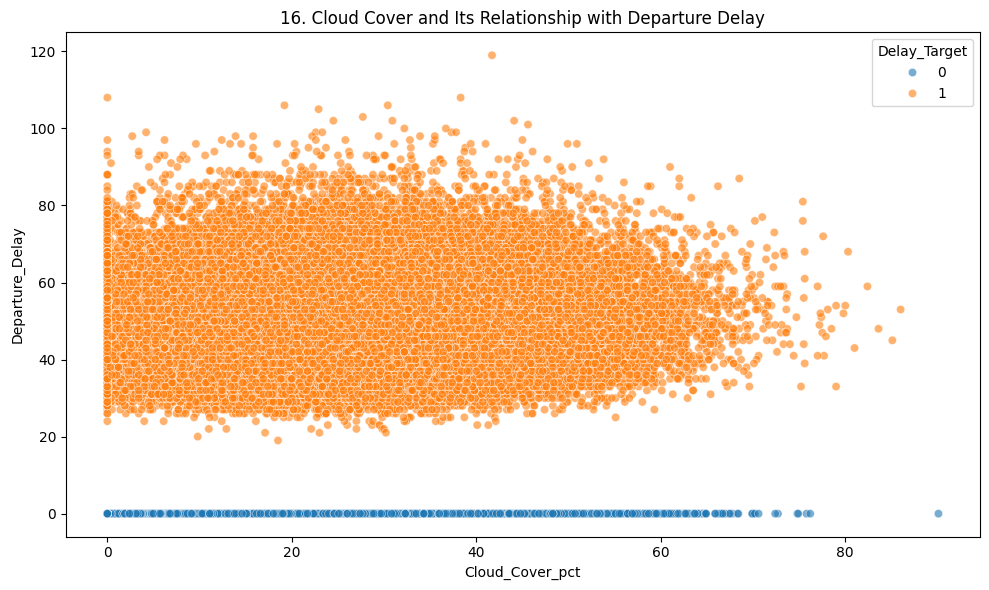

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Cloud_Cover_pct', y='Departure_Delay', hue='Delay_Target', alpha=0.6)
plt.title(f'{plot_no}. Cloud Cover and Its Relationship with Departure Delay')
show_fig()
plot_no += 1

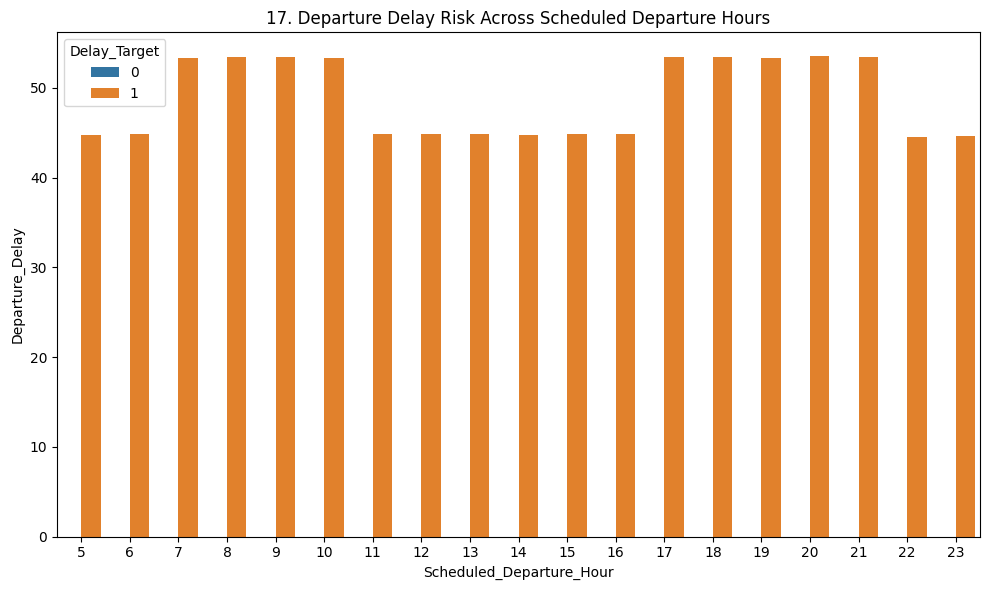

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Scheduled_Departure_Hour', y='Departure_Delay', hue='Delay_Target', errorbar=None)
plt.title(f'{plot_no}. Departure Delay Risk Across Scheduled Departure Hours')
show_fig()
plot_no += 1

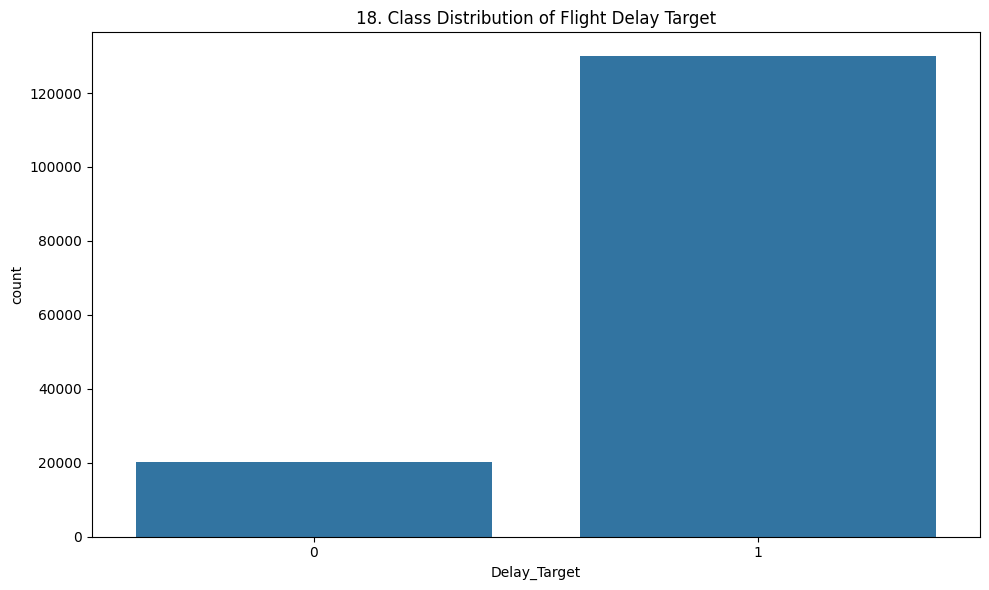

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Delay_Target')
plt.title(f'{plot_no}. Class Distribution of Flight Delay Target')
show_fig()
plot_no += 1

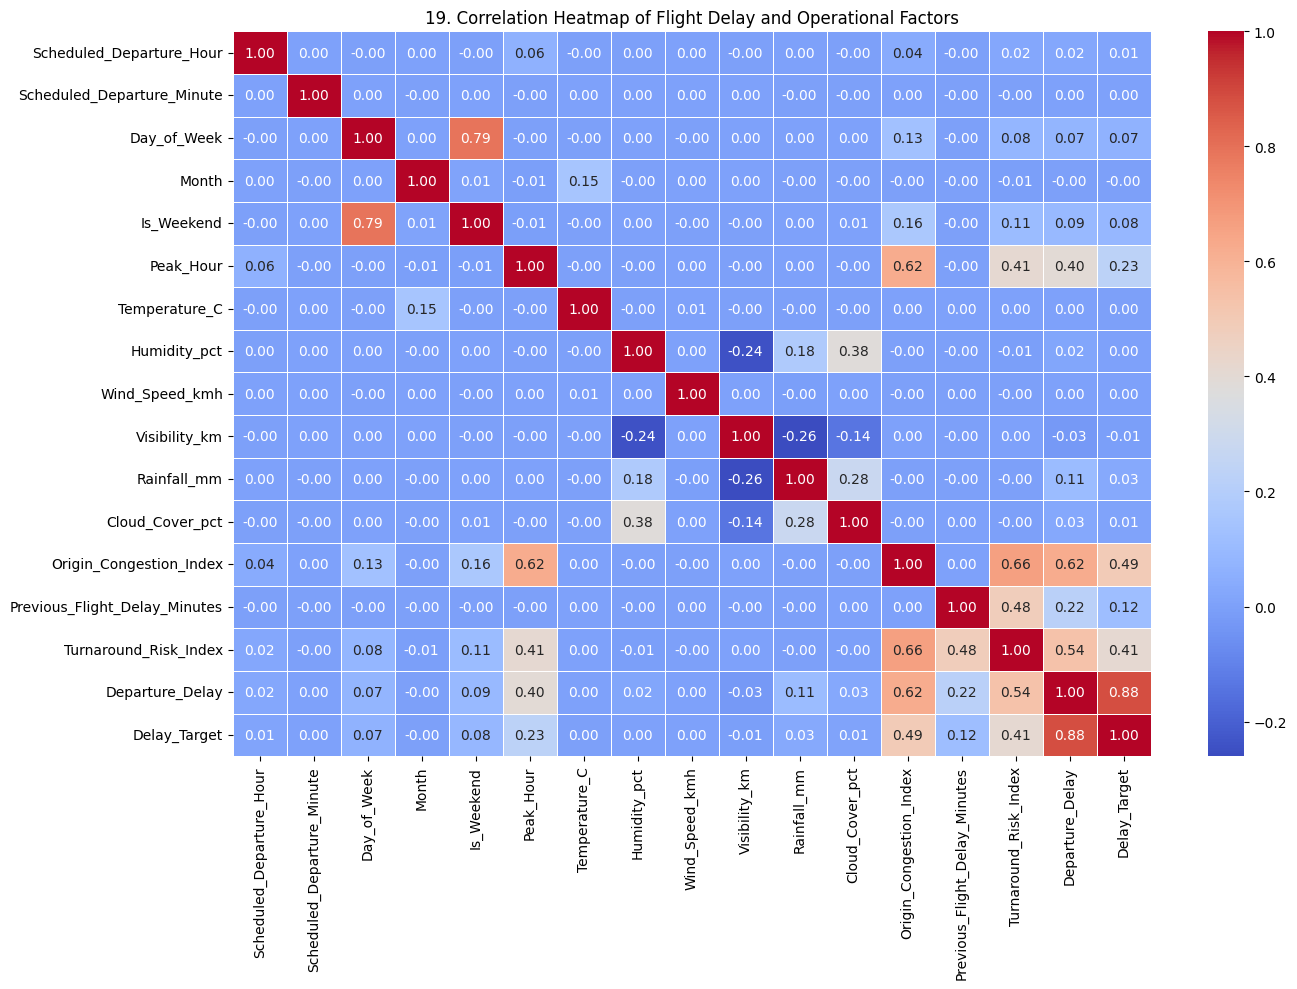

In [31]:
fig = plt.figure(figsize=(14,10))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Flight Delay and Operational Factors')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [32]:
X = df.drop(columns=['Delay_Target', 'Departure_Delay', 'Flight_Date'], errors='ignore')
y = df['Delay_Target']

## Identify numerical and categorical features

In [33]:
numerical_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

## Preprocess features with memory-efficient encoding

In [34]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), categorical_features)
])

## Create a fast supervised model

In [35]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=300,
        C=1.0,
        solver='lbfgs',
        random_state=42
    ))
])

## Split the dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Train the model

In [37]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Scheduled_Departure_Hour', 'Scheduled_Departure_Minute', 'Day_of_Week',
       'Month', 'Is_Weekend', 'Peak_Hour', 'Temperature_C', 'Humidity_pct',
       'Wind_Speed_kmh', 'Visibility_km', 'Rainfall_mm',...
       'Turnaround_Risk_Index'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['Airline', 'Flight_Number', 'Origin_Airport', 'Destination_Airport',
       'Weather'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=300, random_state=42))])

## Generate predictions

In [38]:
y_pred = model.predict(X_test)

## Print model accuracy

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 91.83%


## Display confusion matrix

<Figure size 800x500 with 0 Axes>

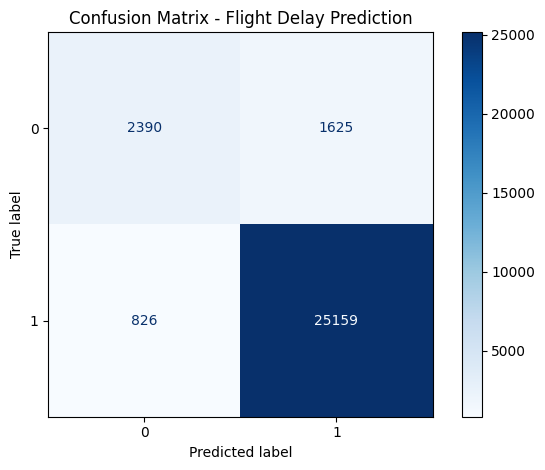

In [40]:
fig = plt.figure(figsize=(8, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    values_format='d',
    cmap='Blues'
)
plt.title('Confusion Matrix - Flight Delay Prediction')
show_fig()